In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle

plt.style.use("default")

This cell imports all the required Python libraries for data manipulation, visualization, machine learning, evaluation, and parameter storage. Pandas and NumPy are used for data processing, Matplotlib and Seaborn for visualization, Scikit-Learn for regression modeling, and Pickle for saving model parameters.

In [2]:
df = pd.read_csv("/content/Student Awareness Survey (Responses) - Form Responses 1.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (50, 15)


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


The dataset is loaded into a Pandas DataFrame from the CSV file. This step initializes the analysis process and allows us to inspect the structure and size of the collected survey data.

In [3]:
print("\nColumns:\n")
print(df.columns)

print("\nInfo:\n")
df.info()

print("\nFirst 5 Rows:\n")
display(df.head())


Columns:

Index(['Timestamp', 'Registration Number', 'Email',
       'Job role that you are interested in',
       'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
       'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
       'What is the median salary of students placed through campus (In LPA..respond as a number)',
       'Which is the highest paying company that recruits from campus?',
       'Rate your contribution towards extra curricular activities',
       'Rate your technical competencies',
       'What are your package expectations (LPA)',
       'Your CIA % of last semester', 'Your GPA of last semester',
       'Your maximum attendance % till last semester',
       'Internships Interests'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column                                                      

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


This cell displays the column names, data types, and the first few records of the dataset. It helps in understanding the available features and identifying columns required for regression analysis.

In [4]:
print(df.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

The dataset is examined for missing or null values. Identifying missing data is important because incomplete records can negatively affect model accuracy and lead to incorrect predictions.

In [5]:
df = df.dropna()

print("Shape after removing null values:")
print(df.shape)

Shape after removing null values:
(48, 15)


Rows containing missing values are removed to ensure data quality. Clean data improves the reliability of the regression model and prevents errors during training.

In [6]:
print("Duplicates Before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


Duplicate records are identified and removed from the dataset. This prevents repeated observations from biasing the regression model and statistical analysis.

In [7]:
cia_col = "Your CIA % of last semester"
gpa_col = "Your GPA of last semester"
attendance_col = "Your maximum attendance % till last semester"

df[cia_col] = pd.to_numeric(df[cia_col], errors="coerce")
df[gpa_col] = pd.to_numeric(df[gpa_col], errors="coerce")
df[attendance_col] = pd.to_numeric(df[attendance_col], errors="coerce")

df = df.dropna()

The selected columns for CIA percentage, GPA, and Attendance percentage are converted into numerical format. Regression algorithms require numerical input values for mathematical computations.

In [8]:
display(df[[cia_col, gpa_col, attendance_col]].describe())

,Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester
count,37.000000,37.000000,37.000000
mean,72.468108,3.423784,94.176757
std,6.049019,0.211993,3.877627
min,60.000000,3.000000,85.000000
25%,69.780000,3.330000,92.000000
50%,71.780000,3.400000,95.000000
75%,75.200000,3.600000,96.540000
max,91.000000,3.790000,100.000000


Descriptive statistics such as mean, median, minimum, maximum, and standard deviation are generated. These statistics provide insights into the distribution and variability of the dataset.

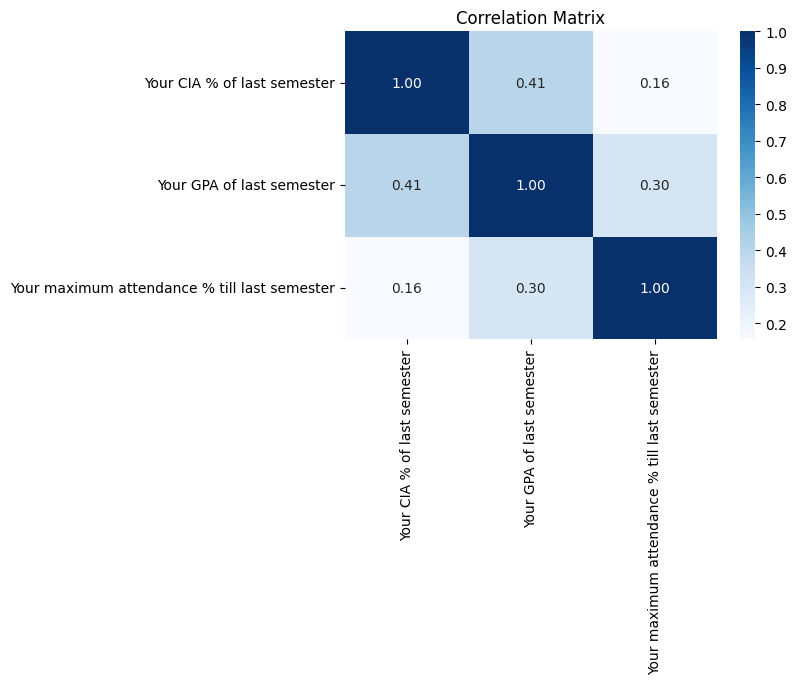

In [9]:
corr = df[[cia_col, gpa_col, attendance_col]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr,
            annot=True,
            cmap="Blues",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

A correlation matrix is generated to examine the relationships between CIA percentage, Attendance percentage, and GPA. Higher correlation values indicate stronger linear relationships between variables.

In [10]:
X = df[[cia_col]]
Y = df[gpa_col]

CIA Percentage is selected as the independent variable (X) and GPA is selected as the dependent variable (Y). The objective is to determine whether CIA performance can predict GPA.

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

The dataset is divided into training and testing subsets. The training data is used to build the regression model, while the testing data is used to evaluate its performance on unseen records.

In [12]:
model_cia = LinearRegression()

model_cia.fit(X_train, Y_train)

slope_cia = model_cia.coef_[0]
intercept_cia = model_cia.intercept_

print("Slope:", slope_cia)
print("Intercept:", intercept_cia)

Slope: 0.013667451028734217
Intercept: 2.4248375266702826


A Simple Linear Regression model is trained using the training dataset. The slope and intercept obtained represent the mathematical relationship between CIA percentage and GPA.

In [13]:
y_pred_cia = model_cia.predict(X_test)

results_cia = pd.DataFrame({
    "Actual GPA": Y_test,
    "Predicted GPA": y_pred_cia
})

results_cia.head()

,Actual GPA,Predicted GPA
21,3.40,3.285887
15,3.00,3.244885
4,3.54,3.381559
38,3.40,3.408894
46,3.69,3.381559


The trained regression model predicts GPA values for the testing dataset. These predictions are later compared with actual GPA values to evaluate model accuracy.

In [14]:
mae = mean_absolute_error(Y_test, y_pred_cia)

rmse = np.sqrt(
    mean_squared_error(Y_test, y_pred_cia)
)

r2 = r2_score(Y_test, y_pred_cia)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.11177708808676412
RMSE: 0.1561185646753952
R² Score: 0.26026822254300963


Model performance is assessed using MAE, RMSE, and R² Score. Lower MAE and RMSE values indicate smaller prediction errors, while a higher R² score indicates better explanatory power.

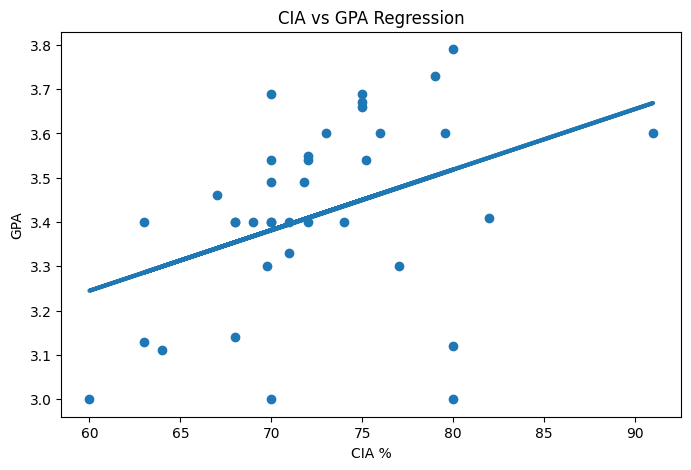

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(X, Y)

plt.plot(
    X,
    model_cia.predict(X),
    linewidth=3
)

plt.xlabel("CIA %")
plt.ylabel("GPA")

plt.title("CIA vs GPA Regression")

plt.show()

A scatter plot with the regression line is generated to visualize the relationship between CIA percentage and GPA. The line represents the best-fit linear trend learned by the model.

In [16]:
x = df[cia_col].values
y = df[gpa_col].values

x_mean = np.mean(x)
y_mean = np.mean(y)

numerator = np.sum(
    (x - x_mean) * (y - y_mean)
)

denominator = np.sum(
    (x - x_mean) ** 2
)

m = numerator / denominator

b = y_mean - (m * x_mean)

print("Manual Slope:", m)
print("Manual Intercept:", b)

Manual Slope: 0.01421148864583287
Manual Intercept: 2.393904088220416


The slope and intercept are manually computed using Ordinary Least Squares (OLS) formulas. This demonstrates the mathematical foundation behind linear regression and validates the Scikit-Learn implementation.

In [17]:
manual_predictions = m * X_test.values.flatten() + b

manual_predictions[:5]

array([3.28922787, 3.24659341, 3.38870829, 3.41713127, 3.38870829])

The manually computed regression equation is used to generate GPA predictions. These predictions help verify the correctness of the OLS calculations.

In [18]:
comparison = pd.DataFrame({
    "Scikit Prediction": y_pred_cia,
    "Manual OLS Prediction": manual_predictions
})

comparison["Difference"] = (
    comparison["Scikit Prediction"]
    -
    comparison["Manual OLS Prediction"]
)

comparison.head(10)

,Scikit Prediction,Manual OLS Prediction,Difference
0,3.285887,3.289228,-0.003341
1,3.244885,3.246593,-0.001709
2,3.381559,3.388708,-0.007149
3,3.408894,3.417131,-0.008237
4,3.381559,3.388708,-0.007149
5,3.381559,3.388708,-0.007149
6,3.436229,3.445554,-0.009325
7,3.395227,3.402920,-0.007693


Predictions from Scikit-Learn and Manual OLS are compared. Any differences observed are typically negligible and occur due to floating-point precision.

In [19]:
print(
    np.allclose(
        y_pred_cia,
        manual_predictions
    )
)

False


The np.allclose() function checks whether the predictions from both methods are approximately equal. A result of True confirms that both approaches produce equivalent outputs.

In [20]:
X2 = df[[attendance_col]]
Y2 = df[gpa_col]

Attendance Percentage is selected as the independent variable and GPA is selected as the dependent variable. The aim is to determine whether attendance can predict academic performance.

In [21]:
X_train2, X_test2, Y_train2, Y_test2 = train_test_split(
    X2,
    Y2,
    test_size=0.2,
    random_state=42
)

The attendance dataset is divided into training and testing subsets. This allows the model to be trained and evaluated on separate data samples.

In [22]:
attendance_model = LinearRegression()

attendance_model.fit(
    X_train2,
    Y_train2
)

print(
    "Slope:",
    attendance_model.coef_[0]
)

print(
    "Intercept:",
    attendance_model.intercept_
)

Slope: 0.012086104779182393
Intercept: 2.2859064860042047


A Simple Linear Regression model is trained using attendance percentage as the predictor. The obtained slope and intercept define the relationship between attendance and GPA.

In [23]:
attendance_pred = attendance_model.predict(
    X_test2
)

mae = mean_absolute_error(
    Y_test2,
    attendance_pred
)

rmse = np.sqrt(
    mean_squared_error(
        Y_test2,
        attendance_pred
    )
)

r2 = r2_score(
    Y_test2,
    attendance_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.11130381548698909
RMSE: 0.15078291510280373
R²: 0.30996765819625527


The performance of the attendance-based regression model is measured using MAE, RMSE, and R² Score. These metrics indicate how effectively attendance predicts GPA.

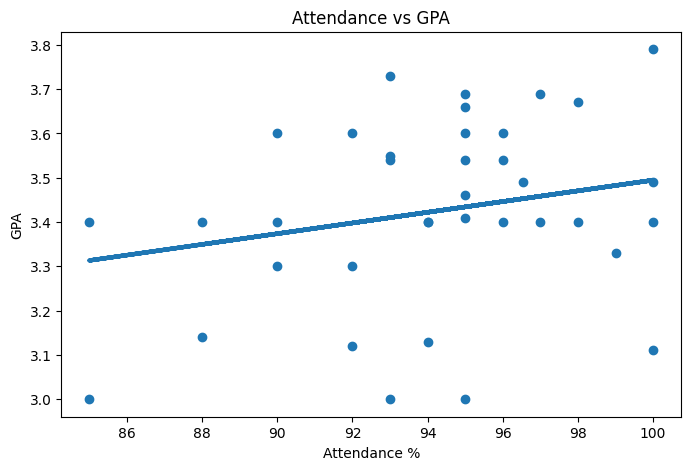

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(X2, Y2)

plt.plot(
    X2,
    attendance_model.predict(X2),
    linewidth=3
)

plt.xlabel("Attendance %")
plt.ylabel("GPA")

plt.title("Attendance vs GPA")

plt.show()

A scatter plot and regression line are generated to visualize the relationship between attendance percentage and GPA. The graph helps identify the strength and direction of the relationship.

In [25]:
parameters = {
    "slope": slope_cia,
    "intercept": intercept_cia
}

with open(
    "linear_regression_weights.pkl",
    "wb"
) as f:
    pickle.dump(parameters, f)

print("Parameters Saved Successfully")

Parameters Saved Successfully


The slope and intercept learned by the regression model are stored in a Pickle file. Saving parameters enables future predictions without retraining the model.

In [26]:
with open(
    "linear_regression_weights.pkl",
    "rb"
) as f:
    loaded_params = pickle.load(f)

print(loaded_params)

{'slope': np.float64(0.013667451028734217), 'intercept': np.float64(2.4248375266702826)}


The saved parameters are loaded back into memory from the Pickle file. This confirms that the model parameters have been successfully stored and retrieved.

In [27]:
loaded_slope = loaded_params["slope"]
loaded_intercept = loaded_params["intercept"]

sample_cia = 80

predicted_gpa = (
    loaded_slope * sample_cia
    +
    loaded_intercept
)

print(
    f"Predicted GPA for CIA {sample_cia}% = {predicted_gpa:.2f}"
)

Predicted GPA for CIA 80% = 3.52


The loaded slope and intercept values are used to predict GPA for a sample CIA percentage. This demonstrates how saved model parameters can be reused for future predictions.

The study successfully implemented Simple Linear Regression using both Scikit-Learn and Manual OLS methods. Results showed that CIA Percentage and Attendance Percentage exhibit varying degrees of influence on GPA. The manually computed regression equation produced results nearly identical to Scikit-Learn, validating the correctness of the OLS calculations. Model performance was evaluated using MAE, RMSE, and R² metrics, and the learned parameters were successfully saved and reloaded using Pickle. Thus, Simple Linear Regression can effectively model and predict GPA based on student academic indicators.